# Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import math

warnings.filterwarnings('error', category=RuntimeWarning)

In [ ]:
def fixTheBox(v, N):
  vSum = np.sum(v, axis=0)
  v = v - vSum[0]/N
  return v

In [ ]:
def positionCornerAtoms(M, a):
  cornerAtomsPositions = []

  faceCoordinates = np.arange(-M*a/2, M*a/2 + a, a)

  for x in faceCoordinates:
    # print(f'x= {x}')
    for y in faceCoordinates:
      # print(f'y= {y}')
      for z in faceCoordinates:
        # print(f'z= {z}')
        cornerAtomsPositions.append([x,y,z])


  return cornerAtomsPositions

In [ ]:
def positionFCAtoms(M, a):
  planeCoordinates = np.arange(-1*(M-1)*a/2, (M-1)*a/2 + a, a)
  # print(planeCoordinates)
  planeDistances = np.arange(-M/2*a, M/2*a + a, a)

  FCAtomsPositions = []

  # Fill xy planes
  for x in planeCoordinates:
    for y in planeCoordinates:
      for z in planeDistances:
        FCAtomsPositions.append([x,y,z])

  # Fill yz planes
  for y in planeCoordinates:
    for z in planeCoordinates:
      for x in planeDistances:
        FCAtomsPositions.append([x,y,z])

  # Fill xz planes
  for x in planeCoordinates:
    for z in planeCoordinates:
      for y in planeDistances:
        FCAtomsPositions.append([x,y,z])

  return FCAtomsPositions

In [ ]:
def initialiseAtomsPositions(M, a):
  # r = []
  # r.append(positionCornerAtoms(M, a))
  # r.append(positionFCAtoms(M, a))
  return positionCornerAtoms(M, a) + positionFCAtoms(M, a)

In [ ]:
def applyMICPerCoordinate(
    currentAtomCoordinate,
    neighbouringAtomCoordinate,
    L
):
  # currentAtomCoordinate = approximate(currentAtomCoordinate)
  # currentAtomCoordinate = approximate(neighbouringAtomCoordinate)

  neighbouringAtomEffectiveCoordinate = neighbouringAtomCoordinate
  diff = currentAtomCoordinate - neighbouringAtomCoordinate

  # N < C
  if diff > L/2:
    neighbouringAtomEffectiveCoordinate = currentAtomCoordinate + L/2 - (diff - L/2)%L
  # N > C
  elif diff < -L/2:
    neighbouringAtomEffectiveCoordinate = currentAtomCoordinate - L/2 + (-diff - L/2)%L


  if math.floor(abs(currentAtomCoordinate - neighbouringAtomEffectiveCoordinate)) > L/2:
    # print("MIC msh sh3'al ya mwlana!")
    # print(f"Current atom's coord: {currentAtomCoordinate}")
    # print(f"Neighbouring atom's coord: {neighbouringAtomCoordinate}")
    # print(f"Coord diff: {diff}")
    # print(f'Changing neighbouring atom coordinate from {neighbouringAtomCoordinate} to {neighbouringAtomEffectiveCoordinate} per MIC')
    # print(f'New diff = {currentAtomCoordinate - neighbouringAtomEffectiveCoordinate}')
    # print(f'L/2 = {L/2}')
    # print()
    print(f'Reapplying MIC w/ currentAtomCoordinate = {currentAtomCoordinate} & ')
    neighbouringAtomEffectiveCoordinate = applyMICPerCoordinate(currentAtomCoordinate, neighbouringAtomCoordinate, L)

  return neighbouringAtomEffectiveCoordinate

In [ ]:
def applyMIC(currentAtomPosition, neighbouringAtomPosition, L):
  # print('Applying MIC in X...')
  neighbouringAtomEffectiveX = applyMICPerCoordinate(
      currentAtomPosition[0],
      neighbouringAtomPosition[0],
      L
  )

  # print('Applying MIC in Y...')
  neighbouringAtomEffectiveY = applyMICPerCoordinate(
      currentAtomPosition[1],
      neighbouringAtomPosition[1],
      L
  )

  # print('Applying MIC in Z...')
  neighbouringAtomEffectiveZ = applyMICPerCoordinate(
      currentAtomPosition[2],
      neighbouringAtomPosition[2],
      L
  )

  return [
      neighbouringAtomEffectiveX,
      neighbouringAtomEffectiveY,
      neighbouringAtomEffectiveZ
  ]

In [ ]:
def lennard_jones_force(positions, L):
    num_points = positions.shape[0]
    dimension = positions.shape[1]

    forces = np.zeros((num_points, dimension))
    stepDistances = []
    distancesCalculationsCount = 0

    for i in range(num_points):
        # print(i)
        for j in range(i + 1, num_points):
            effectiveNeighbouringAtomPosition = applyMIC(
                positions[i],
                positions[j],
                L
            )

            diff = positions[i] - effectiveNeighbouringAtomPosition
            distance = np.linalg.norm(diff)
            stepDistances.append(distance)

            distancesCalculationsCount += 1

            if distance > 1e-12 and distance < 2.5:
            # if distance > 0 and distance < 2.5:
              try:
                # print(distance)
                # Calculate LJ force
                force_magnitude = 48*(1*(distance ** -14) - 0.5*(distance ** -8))
                force = force_magnitude * (diff)
                # print(force)

                # Apply forces to both particles
                forces[i] += force
                forces[j] -= force

              except RuntimeWarning as rw:
                print(f'RTW: {rw}')
                print(f'with dist = {distance}')
                print()

    return forces, stepDistances, distancesCalculationsCount

In [ ]:
def simulate(T0, M, rho, nt, h, TDesired=-1, momentumRescalingPeriod = 20, revert=False):
  m = 48

  sigma = np.sqrt(T0/m)
  a = (4/rho)**(1/3)
  # print(a)
  L = M*(4/rho)**(1/3) + a
  # print(L)

  r = initialiseAtomsPositions(M, a)
  r = np.asarray(r)

  fig = plt.figure()

  ax = fig.add_subplot(111, projection='3d')

  ax.scatter(r[:, 0], r[:, 1], r[:, 2], marker='o')

  N = len(r)
  print(f'N = {N}')

  # Initialise velocity components
  v_x = np.random.normal(0, sigma, N)
  v_y = np.random.normal(0, sigma, N)
  v_z = np.random.normal(0, sigma, N)

  v = np.column_stack((v_x, v_y, v_z))
  v = fixTheBox(v, N)

  F, stepDistances, distancesCalculationsCount = lennard_jones_force(r, L)
  distances = [stepDistances]

  meltingFactor = []
  meltingFactor.append(np.sum(np.cos(4*np.pi*r/a), axis=0))

  T = []
  T.append(16*np.sum(v**2)/N)

  print(f'Simulating for {nt} steps...')

  mrt = 0

  for ti in range(nt):
    print(f'Step {ti}')
    vi = v + h*F/(2*m)

    # Calculate new positions
    r = r + h*vi

    # Calculate new forces
    F, stepDistances, distancesCalculationsCount = lennard_jones_force(r, L)
    distances.append(stepDistances)

    # Calculate new velocities
    v = vi + h*F/(2*m)
    v = fixTheBox(v, N)

    TCurrent = 16*np.sum(v**2)/N
    T.append(TCurrent)
    meltingFactor.append(np.sum(np.cos(4*np.pi*r/a), axis=0).tolist())

    mrt += 1
    if mrt == 20 and TDesired > -1:
      v = np.sqrt(TDesired/TCurrent) * v
      mrt = 0


  print(f'Last time = {(ti +1)*h}')

  if revert:
    # Revert
    # v = -v
    for tr in range(nt):
      vi = (v - F/(2*m))

      # Calculate new positions
      r = r - vi

      # Calculate new forces
      F, stepDistances, distancesCalculationsCount = lennard_jones_force(r, L)

      # Calculate new velocities
      v = vi - F/(2*m)
      # v = fixTheBox(v, N)

  return r, meltingFactor, T, N, distances, distancesCalculationsCount

# Default

## Constants

In [ ]:
TMelting = 0.7
M = 4
rho = 0.85
tf = 15
h = 0.032
nt = math.ceil(tf/h)

time = np.linspace(0, nt*h, nt+1)
TMeltingLine = [TMelting]*len(time)

tEquil = 10
tEquilIndex = round(tEquil/h)
numberOfPostEquilMeasurements = len(time) - tEquilIndex + 1

## T_0 = 0

N = 365
Simulating for 1 steps...
Step 0
Last time = 0.032


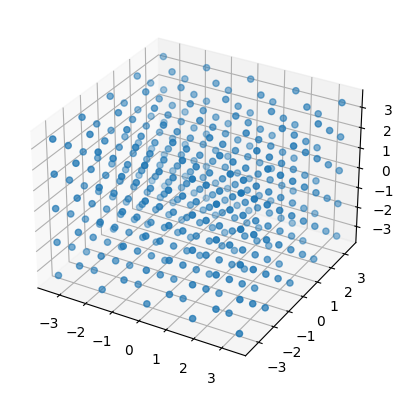

In [ ]:
T00 = 0

r0, meltingFactor0, T0, N, _, _ = simulate(T00, M, rho, 1, h)

# fig = plt.figure()

# ax = fig.add_subplot(111, projection='3d')

# Plot the points
# ax.scatter(r0[:, 0], r0[:, 1], r0[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor0, yMeltingFactor0, zMeltingFactor0 = zip(*meltingFactor0)

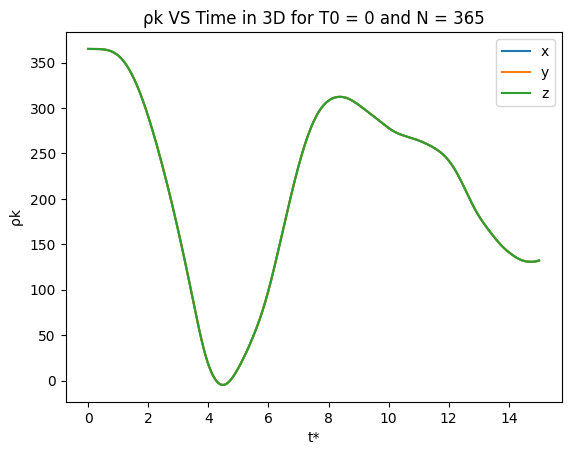

In [ ]:
plt.plot(time, xMeltingFactor0, label='x')
plt.plot(time, yMeltingFactor0, label='y')
plt.plot(time, zMeltingFactor0, label='z')


# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time in 3D for T0 = {T00} and N = {N}')

# Show legend
plt.legend()


# Display the plot
plt.show()

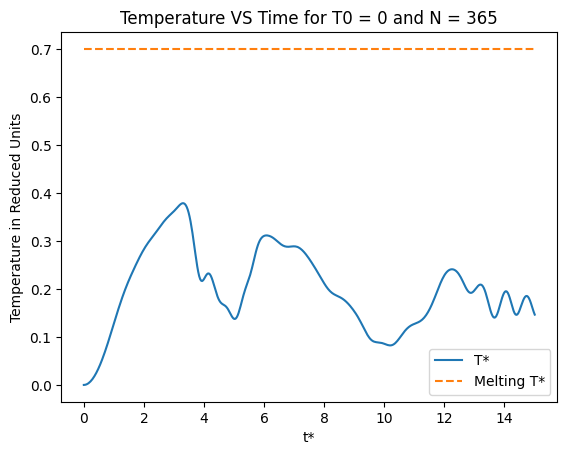

In [ ]:
plt.plot(time, T0, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time for T0 = {T00} and N = {N}')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT0 = np.sum(T0[tEquilIndex:])/numberOfPostEquilMeasurements
averageT0

0.1652473558224992

## T_0 = 1

N = 365
Simulating for 469 steps...
Step 0
Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45
Step 46
Step 47
Step 48
Step 49
Step 50
Step 51
Step 52
Step 53
Step 54
Step 55
Step 56
Step 57
Step 58
Step 59
Step 60
Step 61
Step 62
Step 63
Step 64
Step 65
Step 66
Step 67
Step 68
Step 69
Step 70
Step 71
Step 72
Step 73
Step 74
Step 75
Step 76
Step 77
Step 78
Step 79
Step 80
Step 81
Step 82
Step 83
Step 84
Step 85
Step 86
Step 87
Step 88
Step 89
Step 90
Step 91
Step 92
Step 93
Step 94
Step 95
Step 96
Step 97
Step 98
Step 99
Step 100
Step 101
Step 102
Step 103
Step 104
Step 105
Step 106
Step 107
Step 108
Step 109
Step 110
Step 111
Step 112
Step 113
Step 114
Step 115
Step 116
Step 117
Step 118
Ste

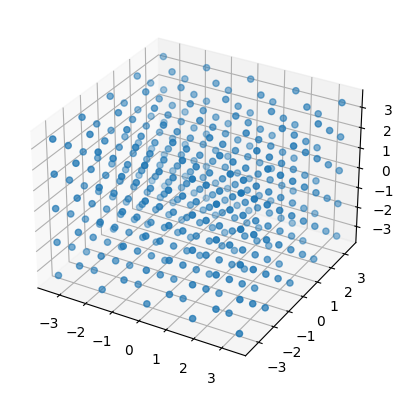

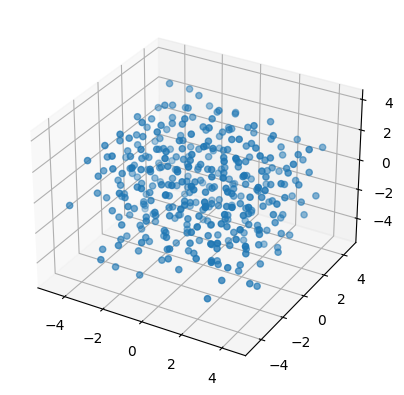

In [ ]:
T01 = 1

r1, meltingFactor1, T1, N, _, _ = simulate(T01, M, rho, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r1[:, 0], r1[:, 1], r1[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor1, yMeltingFactor1, zMeltingFactor1 = zip(*meltingFactor1)

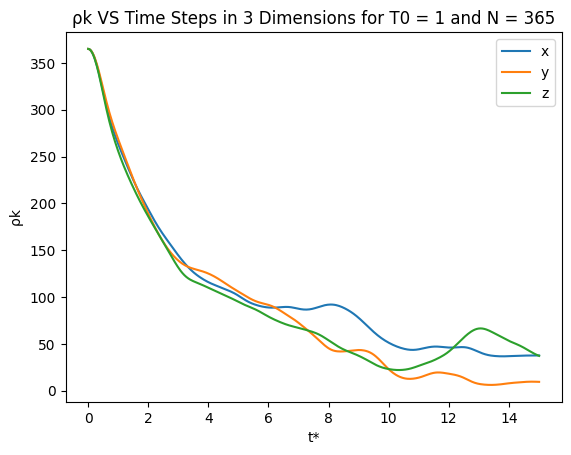

In [ ]:
plt.plot(time, xMeltingFactor1, label='x')
plt.plot(time, yMeltingFactor1, label='y')
plt.plot(time, zMeltingFactor1, label='z')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time Steps in 3 Dimensions for T0 = {T01} and N = {N}')

# Show legend
plt.legend()

# Display the plot
plt.show()

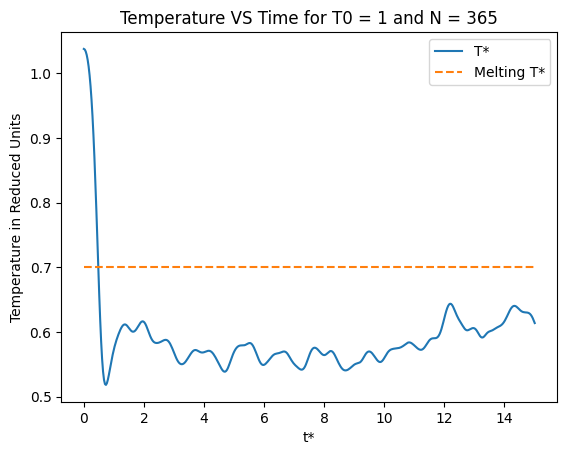

In [ ]:
plt.plot(time, T1, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time for T0 = {T01} and N = {N}')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT1 = np.sum(T1[tEquilIndex:])/numberOfPostEquilMeasurements
averageT1

0.5990094293082994

## T_0 = 2

N = 365
Simulating for 469 steps...
Last time = 15.008000000000001


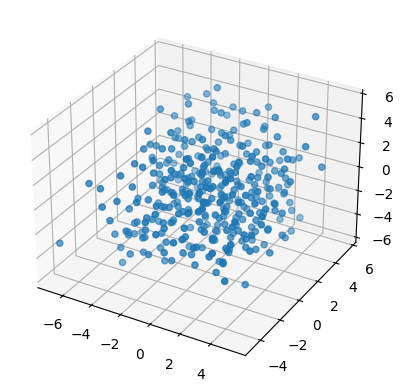

In [ ]:
T02 = 2
M = 4
rho = 0.85
tf = 15
h = 0.032
nt = math.ceil(tf/h)

r2, meltingFactor2, T2, N = simulate(T02, M, rho, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r2[:, 0], r2[:, 1], r2[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor2, yMeltingFactor2, zMeltingFactor2 = zip(*meltingFactor2)

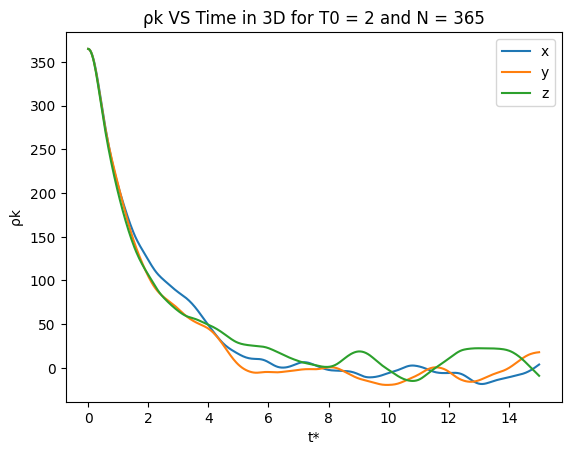

In [ ]:
plt.plot(time, xMeltingFactor2, label='x')
plt.plot(time, yMeltingFactor2, label='y')
plt.plot(time, zMeltingFactor2, label='z')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time in 3D for T0 = {T02} and N = {N}')

# Show legend
plt.legend()

# Display the plot
plt.show()

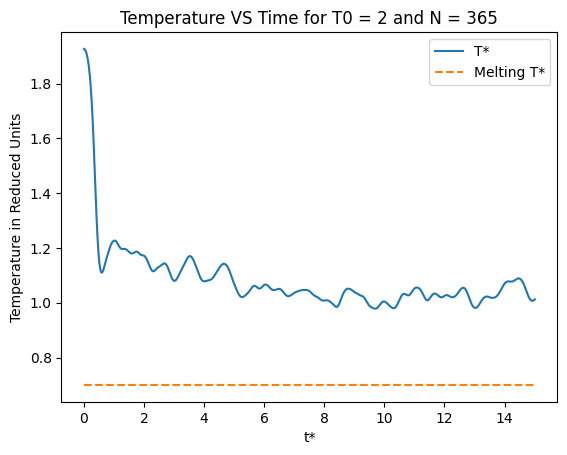

In [ ]:
plt.plot(time, T2, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time for T0 = {T02} and N = {N}')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT2 = np.sum(T2[tEquilIndex:])/numberOfPostEquilMeasurements
averageT2

1.0230320926986332

# Momentum Rescaling

## Constants

In [ ]:
TMelting = 0.7
M = 4
rho = 0.85
tf = 15
h = 0.032
nt = math.ceil(tf/h)

time = np.linspace(0, nt*h, nt+1)
TMeltingLine = [TMelting]*len(time)

tEquil = 10
tEquilIndex = round(tEquil/h)
postEquilTime = time[-1] - time[tEquilIndex]

## T0 = 0

N = 365
Simulating for 469 steps...
Last time = 15.008000000000001


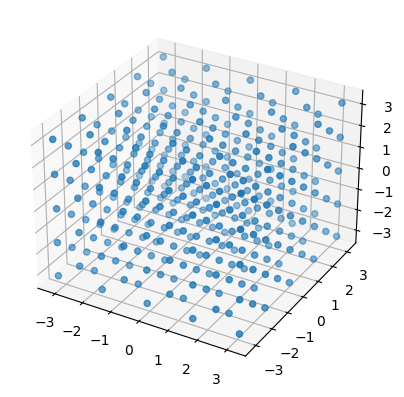

In [ ]:
T00r = 0

r0r, meltingFactor0r, T0r, N = simulate(T00r, M, rho, nt, h, T00r)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r0r[:, 0], r0r[:, 1], r0r[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor0r, yMeltingFactor0r, zMeltingFactor0r = zip(*meltingFactor0r)

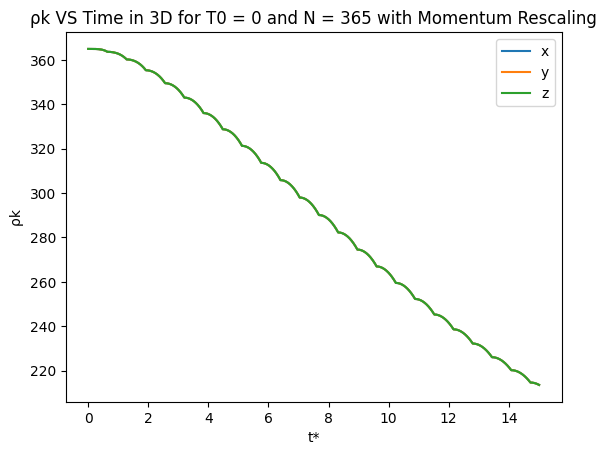

In [ ]:
plt.plot(time, xMeltingFactor0r, label='x')
plt.plot(time, yMeltingFactor0r, label='y')
plt.plot(time, zMeltingFactor0r, label='z')


# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time in 3D for T0 = {T00r} and N = {N} with Momentum Rescaling')

# Show legend
plt.legend()


# Display the plot
plt.show()

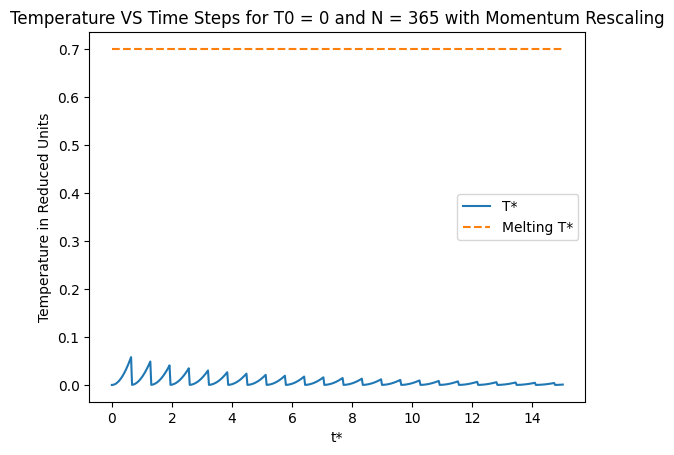

In [ ]:
plt.plot(time, T0r, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time Steps for T0 = {T00r} and N = {N} with Momentum Rescaling')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT0 = np.sum(T0r[tEquilIndex:])/postEquilTime
averageT0

0.07171659487087581

## T0 = 1

N = 365
Simulating for 469 steps...
Last time = 15.008000000000001


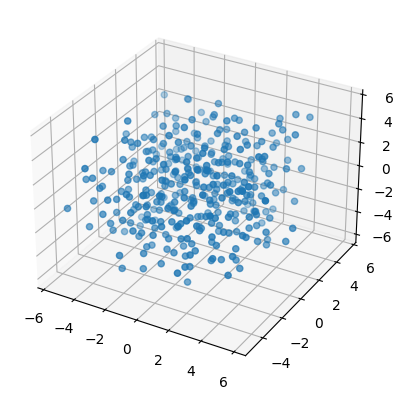

In [ ]:
T01r = 1

r1r, meltingFactor1r, T1r, N = simulate(T01r, M, rho, nt, h, T01r)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r1r[:, 0], r1r[:, 1], r1r[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor1r, yMeltingFactor1r, zMeltingFactor1r = zip(*meltingFactor1r)

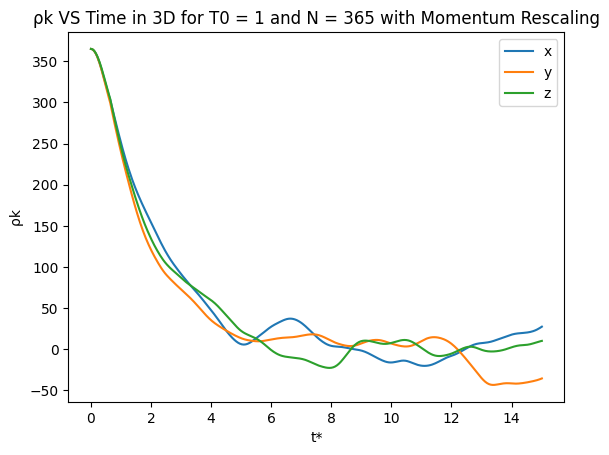

In [ ]:
plt.plot(time, xMeltingFactor1r, label='x')
plt.plot(time, yMeltingFactor1r, label='y')
plt.plot(time, zMeltingFactor1r, label='z')


# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time in 3D for T0 = {T01r} and N = {N} with Momentum Rescaling')

# Show legend
plt.legend()


# Display the plot
plt.show()

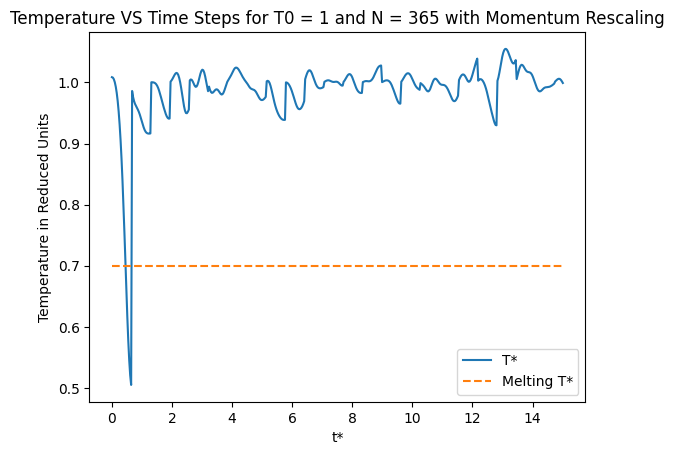

In [ ]:
plt.plot(time, T1r, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time Steps for T0 = {T01r} and N = {N} with Momentum Rescaling')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT1 = np.sum(T1r[tEquilIndex:])/postEquilTime
averageT1

31.49885201820426

## T0 = 2

N = 365
Simulating for 469 steps...
Last time = 15.008000000000001


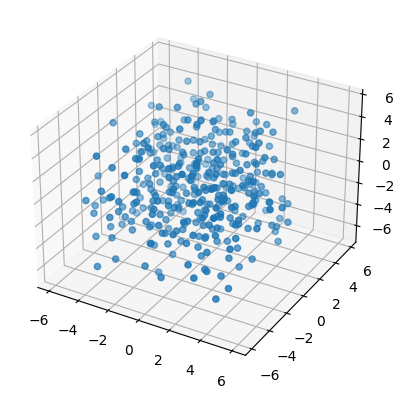

In [ ]:
T02r = 2
M = 4
rho = 0.85
tf = 15
h = 0.032
nt = math.ceil(tf/h)

r2r, meltingFactor2r, T2r, N = simulate(T02r, M, rho, nt, h, T02r)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r2r[:, 0], r2r[:, 1], r2r[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor2r, yMeltingFactor2r, zMeltingFactor2r = zip(*meltingFactor2r)

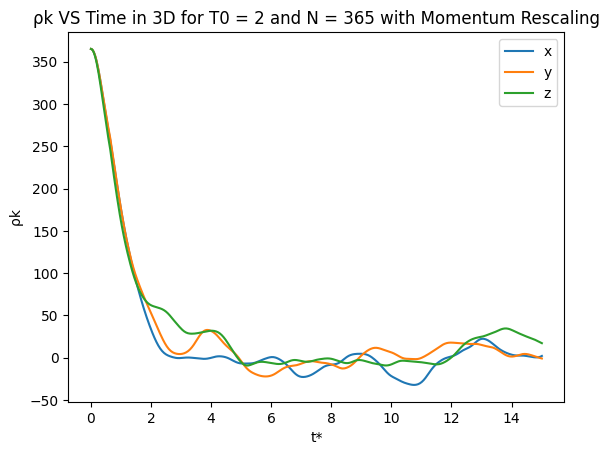

In [ ]:
plt.plot(time, xMeltingFactor2r, label='x')
plt.plot(time, yMeltingFactor2r, label='y')
plt.plot(time, zMeltingFactor2r, label='z')


# Adding labels and title
plt.xlabel('t*')
plt.ylabel('ρk​')
plt.title(f'ρk​ VS Time in 3D for T0 = {T02r} and N = {N} with Momentum Rescaling')

# Show legend
plt.legend()


# Display the plot
plt.show()

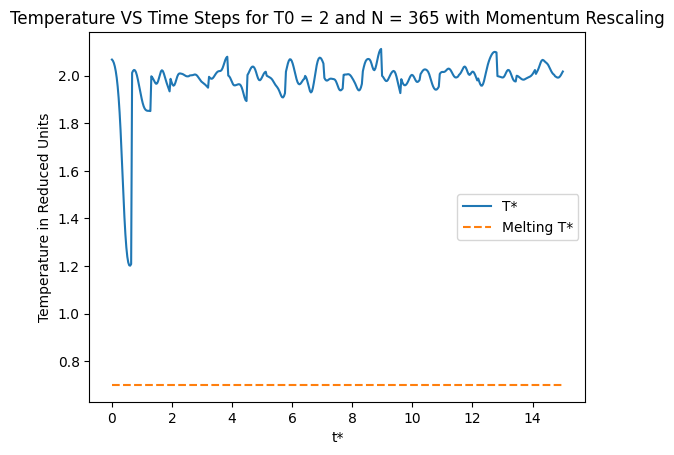

In [ ]:
plt.plot(time, T2r, label='T*')
plt.plot(time, TMeltingLine, linestyle='--', label='Melting T*')

# Adding labels and title
plt.xlabel('t*')
plt.ylabel('Temperature in Reduced Units')
plt.title(f'Temperature VS Time Steps for T0 = {T02r} and N = {N} with Momentum Rescaling')

plt.legend()

# Display the plot
plt.show()

In [ ]:
averageT2 = np.sum(T2r[tEquilIndex:])/postEquilTime
averageT2

63.18089304711679

# Reduced Distances Calculations

## Constants

In [ ]:
M = 4
tf = 15
h = 0.032
nt = math.ceil(tf/h)

time = np.linspace(0, nt*h, nt+1)
bin_size = 0.05

## T_0 = 0, ρ = 0.85

N = 365
Simulating for 469 steps...
Last time = 15.008000000000001


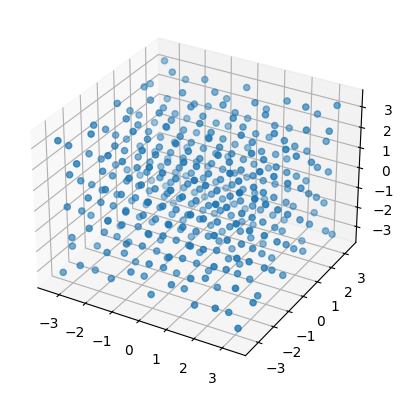

In [ ]:
T00d = 0
rho = 0.85

r0d, meltingFactor0d, T0d, N, distances0d, distancesCalculationsCount0d = simulate(T00d, M, rho, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r0[:, 0], r0[:, 1], r0[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

xMeltingFactor0d, yMeltingFactor0d, zMeltingFactor0d = zip(*meltingFactor0)

In [ ]:
histogramCountsSums = []
histograms = []
for distances0d_t in distances0d:
  # Calculate the range for bins based on the data
  data_range = 2.5 - min(distances0d_t)
  num_bins = int(data_range / bin_size)

  # Creating the histogram with specified bin size
  counts, bins, _ = plt.hist(distances0d_t, bins=num_bins, range=(min(distances0d_t), 2.5))
  plt.close()
  counts = np.array(counts)
  bins = np.array(bins)
  histograms.append([bins, counts])
  histogramCountsSums.append(np.sum(counts))

Text(0, 0.5, 'g(r*)')

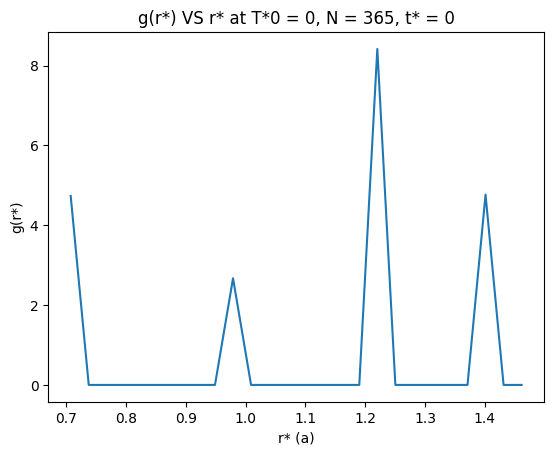

In [ ]:
a = (4/rho)**(1/3)

plt.plot(histograms[0][0][:-1]/a, histograms[0][1] / N)
plt.title(f'g(r*) VS r* at T*0 = {T00d}, N = {N}, t* = 0')
plt.xlabel('r* (a)')
plt.ylabel('g(r*)')

Text(0, 0.5, 'g(r*)')

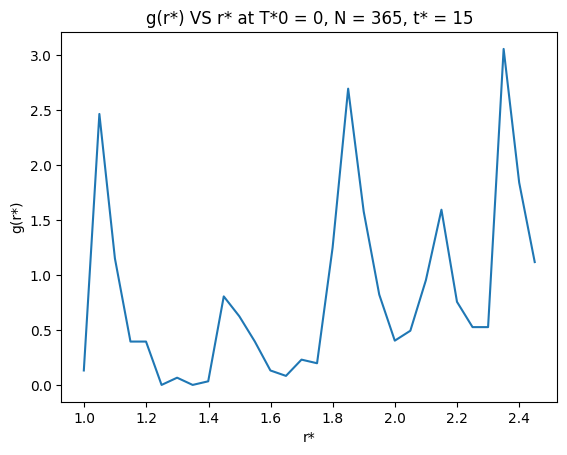

In [ ]:
plt.plot(histograms[-1][0][:-1], histograms[-1][1] / N)
plt.title(f'g(r*) VS r* at T*0 = {T00d}, N = {N}, t* = 15')
plt.xlabel('r*')
plt.ylabel('g(r*)')

In [ ]:
# histogramCountsSums = np.array(histogramCountsSums)
# meanSquaredDistance = histogramCountsSums/(4*np.pi*bin_size*histogramCountsSums**2)
# plt.plot(time, meanSquaredDistance)
# plt.title('<r*(t*)^2> VS Time at T*0 = 0, N = 365')
# plt.xlabel('t*')
# plt.ylabel('<r*(t*)^2>')

# distances0d = np.array(distances0d)
# distancesSum = np.sum(distances0d, axis=1)
# meanSquaredDistance = distancesSum/(4*np.pi*bin_size*distancesSum**2)
# plt.plot(time, meanSquaredDistance)
# plt.title('<r*(t*)^2> VS Time at T*0 = 0, N = 365')
# plt.xlabel('t*')
# plt.ylabel('<r*(t*)^2>')

Text(0, 0.5, '<r*(t*)^2>')

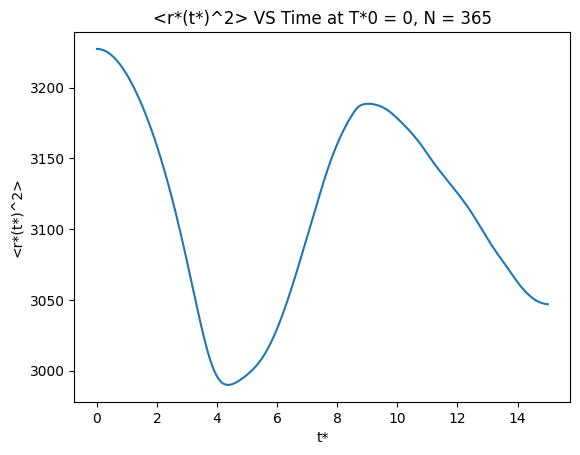

In [ ]:
distances0d = np.array(distances0d)
squaredDistancesSum0d = np.sum(distances0d**2, axis=1)
meanSquaredDistance0d = squaredDistancesSum0d/(N)
plt.plot(time, meanSquaredDistance0d)
plt.title('<r*(t*)^2> VS Time at T*0 = 0, N = 365')
plt.xlabel('t*')
plt.ylabel('<r*(t*)^2>')

In [ ]:
distances0d = np.array(distances0d)
meltingFactor0d = np.sum(distances0d, axis=1)/(rho*316000/365)
plt.plot(time, meltingFactor0d)
plt.title('ρk VS Time at T*0 = 0, N = 365')
plt.xlabel('t*')
plt.ylabel('ρk')

NameError: ignored

## T_0 = 0.5,  ρ = 1.2



In [ ]:
T005d = 0.5
rho05d = 1.2
M05d = 3

r05d, meltingFactor05d, T05d, N05d, distances05d, distancesCalculationsCount05d = simulate(T005d, M05d, rho05d, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r05d[:, 0], r05d[:, 1], r05d[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

In [ ]:
histogramCountsSums = []
histograms = []
for distances05d_t in distances05d:
  # Calculate the range for bins based on the data
  data_range = 2.5 - min(distances05d_t)
  num_bins = int(data_range / bin_size)

  # Creating the histogram with specified bin size
  counts05d, bins05d, _ = plt.hist(distances05d_t, bins=num_bins, range=(min(distances05d_t), 2.5))
  plt.close()
  counts = np.array(counts05d)
  bins05d = np.array(bins05d)
  histograms.append([bins05d, counts05d])
  histogramCountsSums.append(np.sum(counts05d))

Text(0, 0.5, 'g(r*)')

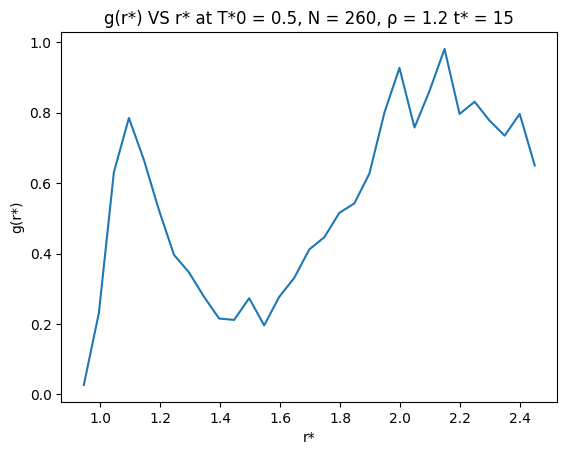

In [ ]:
plt.plot(histograms[-1][0][:-1], histograms[-1][1] / N05d)
plt.title(f'g(r*) VS r* at T*0 = {T005d}, N = {N05d}, ρ = {rho05d} t* = 15')
plt.xlabel('r*')
plt.ylabel('g(r*)')

Text(0, 0.5, '<r*(t*)^2>')

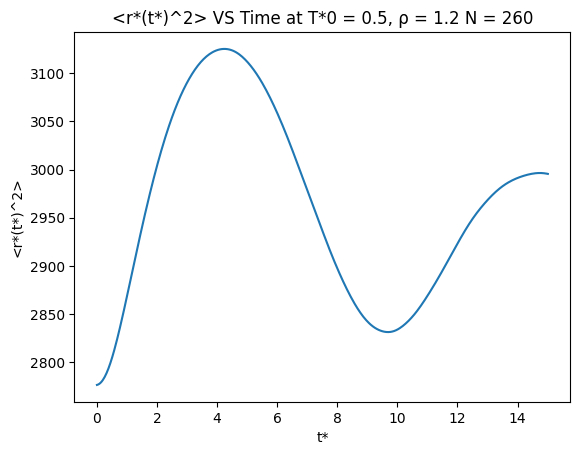

In [ ]:
distances05d = np.array(distances05d)
squaredDistancesSum05d = np.sum(distances05d**2, axis=1)
meanSquaredDistance05d = squaredDistancesSum05d/(N)
plt.plot(time, meanSquaredDistance05d)
plt.title(f'<r*(t*)^2> VS Time at T*0 = {T005d}, ρ = {rho05d} N = {N05d}')
plt.xlabel('t*')
plt.ylabel('<r*(t*)^2>')

Text(0, 0.5, 'ρk')

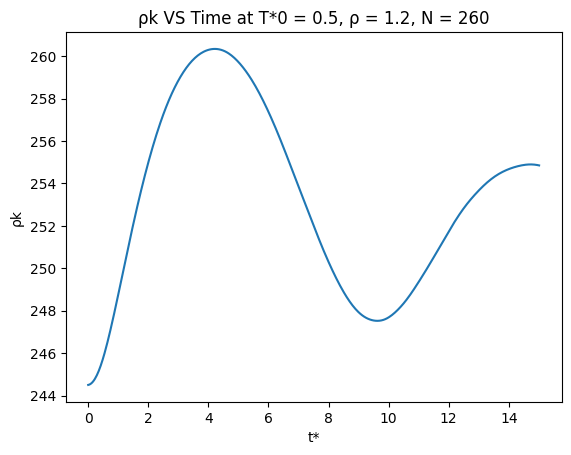

In [ ]:
distances05d = np.array(distances05d)
meltingFactor05d = np.sum(distances05d, axis=1)/(rho*129000/260)
plt.plot(time, meltingFactor05d)
plt.title(f'ρk VS Time at T*0 = {T005d}, ρ = {rho05d}, N = {N05d}')
plt.xlabel('t*')
plt.ylabel('ρk')

## T_0 = 1,  ρ = *0.8*

In [ ]:
T01d = 1
rho1d = 0.8
M1d = 4

r1d, meltingFactor1d, T1d, N1d, distances1d, distancesCalculationsCount1d = simulate(T01d, M1d, rho1d, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r1d[:, 0], r1d[:, 1], r1d[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

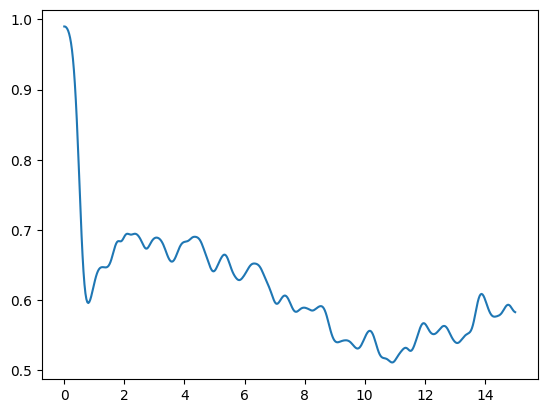

In [ ]:
plt.plot(time, T1d)

In [ ]:
histogramCountsSums1d = []
histograms1d = []
for distances05d_t in distances05d:
  # Calculate the range for bins based on the data
  data_range = 2.5 - min(distances05d_t)
  num_bins = int(data_range / bin_size)

  # Creating the histogram with specified bin size
  counts05d, bins05d, _ = plt.hist(distances05d_t, bins=num_bins, range=(min(distances05d_t), 2.5))
  plt.close()
  counts = np.array(counts05d)
  bins05d = np.array(bins05d)
  histograms1d.append([bins05d, counts05d])
  histogramCountsSums1d.append(np.sum(counts05d))

Text(0, 0.5, 'g(r*)')

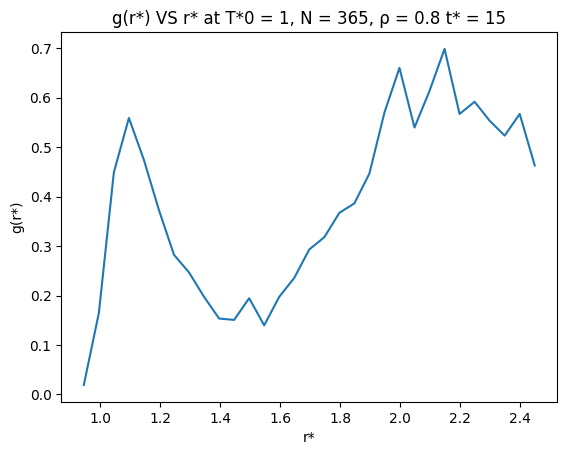

In [ ]:
plt.plot(histograms1d[-1][0][:-1], histograms1d[-1][1] / N1d)
plt.title(f'g(r*) VS r* at T*0 = {T01d}, N = {N1d}, ρ = {rho1d} t* = 15')
plt.xlabel('r*')
plt.ylabel('g(r*)')

Text(0, 0.5, '<r*(t*)^2>')

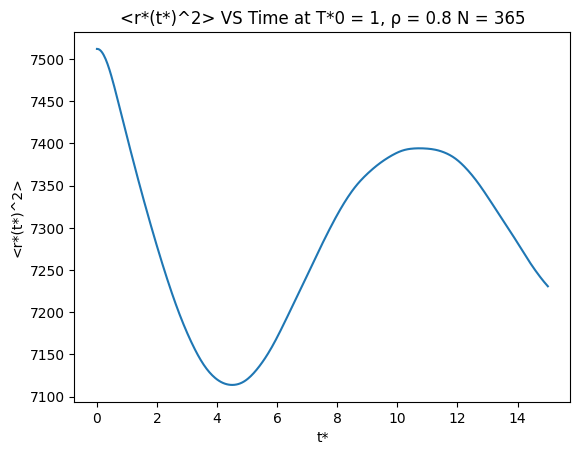

In [ ]:
distances1d = np.array(distances1d)
squaredDistancesSum1d = np.sum(distances1d**2, axis=1)
meanSquaredDistance05d = squaredDistancesSum1d/(N)
plt.plot(time, meanSquaredDistance05d)
plt.title(f'<r*(t*)^2> VS Time at T*0 = {T01d}, ρ = {rho1d} N = {N1d}')
plt.xlabel('t*')
plt.ylabel('<r*(t*)^2>')

Text(0, 0.5, 'ρk')

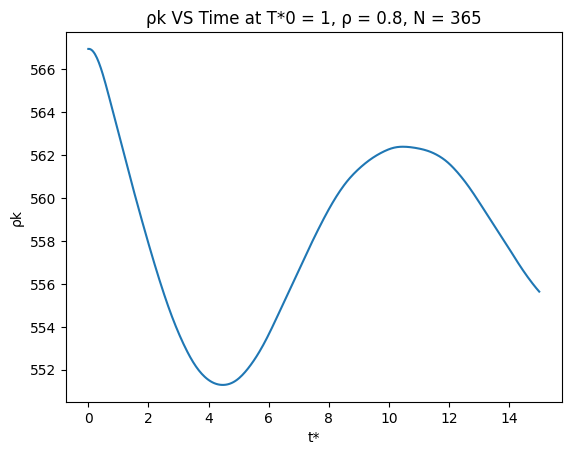

In [ ]:
distances1d = np.array(distances1d)
newMeltingFactor1d = np.sum(distances1d, axis=1)/(rho*129000/260)
plt.plot(time, newMeltingFactor1d)
plt.title(f'ρk VS Time at T*0 = {T01d}, ρ = {rho1d}, N = {N1d}')
plt.xlabel('t*')
plt.ylabel('ρk')

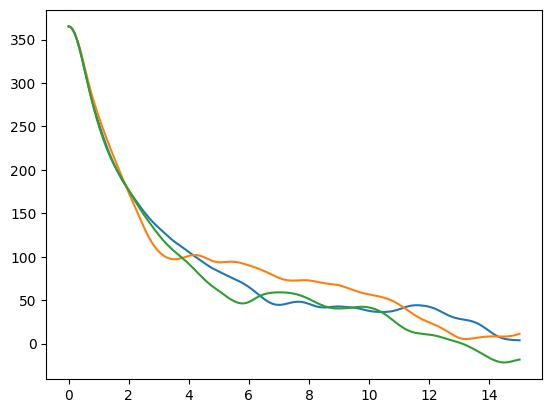

In [ ]:
plt.plot(time, meltingFactor1d)

## T_0 = 3,  ρ = *0.3*

In [ ]:
T03d = 3
rho3d = 0.3
M1d = 3

r3d, meltingFactor3d, T3d, N3d, distances3d, distancesCalculationsCount3d = simulate(T03d, M1d, rho3d, nt, h)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(r3d[:, 0], r3d[:, 1], r3d[:, 2], marker='o')
# ax.set_xlim([-0.5, 0.5])
# ax.set_ylim([-0.5, 0.5])
# ax.set_zlim([-0.5, 0.5])

N = 260
Simulating for 469 steps...
Step 0
Step 1
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC...
Reapplying MIC

RecursionError: ignored